In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Temporal array parameters
tmin = 0
tmax = 6052 * 2
dt = 10

# Gravitational Parameters
mu = 398600.4415
m_earth = 5.9726e24

# Initial conditions [x1, y1, z1,  vx1, vy1, vz1,    x2, y2, z2,  vx2, vy2, vz2]
x0 = [0., 0., 0.,  0., 0., 0.,  4604.49276873138, 1150.81472538679, 4694.55079634563,  -5.10903235110107, -2.48824074138143, 5.62098648967432]

# Integration function
def F(t, x):
    F = np.zeros(len(x0))
    
    dx = x[0] - x[6]
    dy = x[1] - x[7]
    dz = x[2] - x[8]
    dist_cubed = (dx**2 + dy**2 + dz**2) ** 1.5
    
    F[0], F[1], F[2] = x[3], x[4], x[5]
    F[6], F[7], F[8] = x[9], x[10], x[11]

    F[3] = 0.
    F[4] = 0.
    F[5] = 0.
    
    F[9] =   mu * dx / dist_cubed
    F[10] =  mu * dy / dist_cubed
    F[11] =  mu * dz / dist_cubed
    
    return F



# Define lists
E_K, E_P, E_tot = [], [], []
L = []



# Total energy function
def Total_energy(x):
    kinetic_energy, potential_energy = 0, 0
    
    for i in range(0, len(x), 6):
        vx = x[i+3]
        vy = x[i+4]
        vz = x[i+5]
        kinetic_energy += 0.5  * (vx**2 + vy**2 + vz**2)
    
    for i in range(0, len(x), 6):
        for j in range(i + 6, len(x), 6):
            dx = x[i] - x[j]
            dy = x[i+1] - x[j+1]
            dz = x[i+2] - x[j+2]
            r = np.sqrt(dx**2 + dy**2 + dz**2)
            potential_energy += - mu / r
            
    return kinetic_energy, potential_energy, kinetic_energy + potential_energy


# Total angular momentum function
def Total_angular_momentum(x):
    r1 = np.array([x[0], x[1], x[2]])  
    v1 = np.array([x[3], x[4], x[5]])  
    r2 = np.array([x[6], x[7], x[8]]) 
    v2 = np.array([x[9], x[10], x[11]])
    
    L1 = np.cross(r1, v1)
    L2 = np.cross(r2, v2)
    
    L_total = L1 + L2
    return np.linalg.norm(L_total)


# Integration
T = np.arange(tmin, tmax, dt)
s = solve_ivp(F, [tmin, tmax], x0, method='RK45', t_eval=T, rtol=1e-12, atol=1e-12)

# Initial energy and angular momentum
E0 = Total_energy(x0)
L0 = Total_angular_momentum(x0)

# Saving energy and angular momentum data
for i in range(len(T)):
    E_K.append(Total_energy(s.y[:, i])[0])
    E_P.append(Total_energy(s.y[:, i])[1])
    E_tot.append(Total_energy(s.y[:, i])[2])
    L.append(Total_angular_momentum(s.y[:,i]) - L0)
    
# Saving trajectories data
X1, Y1, Z1 = s.y[0], s.y[1], s.y[2]
X2, Y2, Z2 = s.y[6], s.y[7], s.y[8]


TypeError: F() takes 1 positional argument but 2 were given

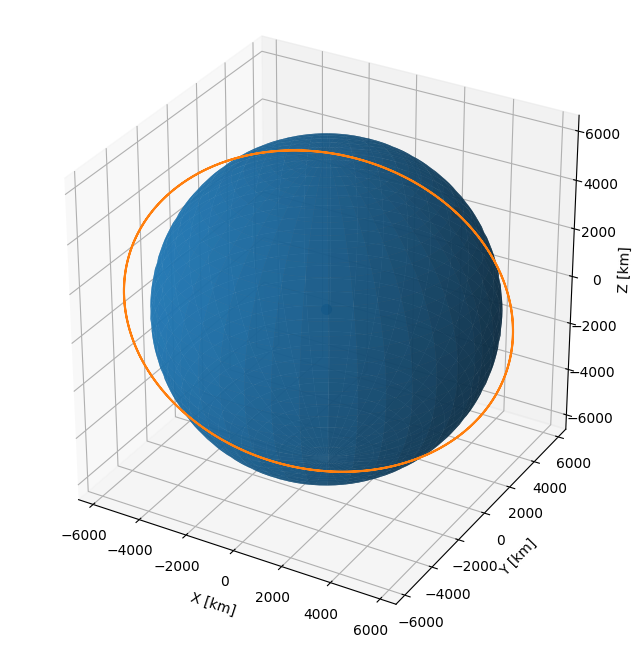

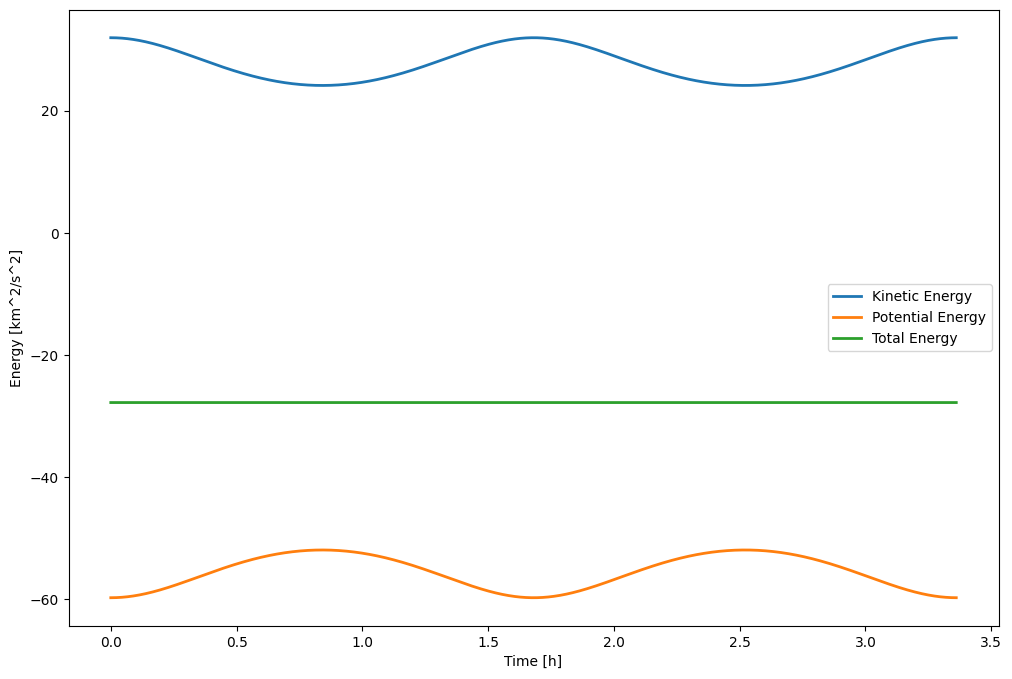

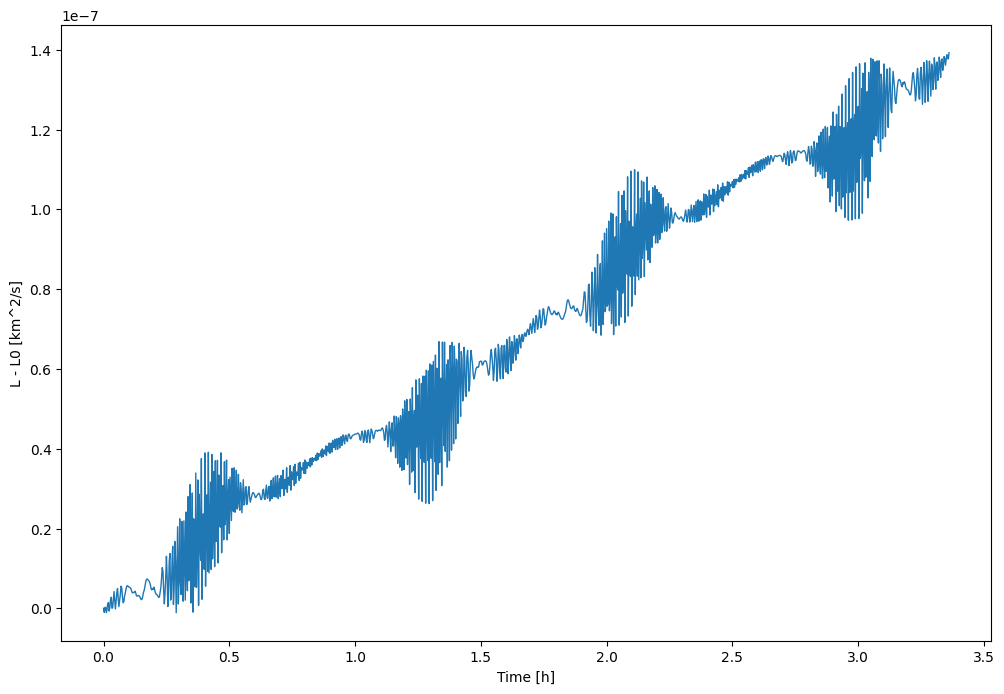

In [109]:
import numpy as np
import matplotlib.pyplot as plt


# --- crea l'axes 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# --- traiettoria (esempio: X1,Y1,Z1 e X2,Y2,Z2 già definiti) ---
ax.plot3D(X1, Y1, Z1, label="Satellite", color="tab:orange", zorder=10)
# ax.plot3D(X2, Y2, Z2, label="Altro corpo")  # opzionale

# --- Terra in scala (centro all'origine; cambia x0,y0,z0 se serve) ---
RE = 6371.0
x0, y0, z0 = 0.0, 0.0, 0.0
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0, np.pi, 80)
xs = x0 + RE*np.outer(np.cos(u), np.sin(v))
ys = y0 + RE*np.outer(np.sin(u), np.sin(v))
zs = z0 + RE*np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(xs, ys, zs, color="tab:blue", alpha=0.8, linewidth=0, label="Earth", zorder=-1)

ax.plot3D(X1, Y1, Z1, label="Earth")
ax.plot3D(X2, Y2, Z2, label="Satellite", zorder=10)
ax.scatter3D(X1[0], Y1[0], Z1[0], s=50, zorder=-1)
ax.scatter3D(X2[0], Y2[0], Z2[0], s=50, zorder=10)

# --- etichette/legenda ---
ax.set_xlabel("X [km]"); ax.set_ylabel("Y [km]"); ax.set_zlabel("Z [km]")



# --- proporzioni uguali (sfera non schiacciata) ---
data_ranges = np.array([
    X1.max()-X1.min(), Y1.max()-Y1.min(), Z1.max()-Z1.min(), 2*RE, 2*RE, 2*RE
])
R = data_ranges.max()/2
cx = (X1.max()+X1.min())/2; cy = (Y1.max()+Y1.min())/2; cz = (Z1.max()+Z1.min())/2
ax.set_xlim(cx-R, cx+R); ax.set_ylim(cy-R, cy+R); ax.set_zlim(cz-R, cz+R)
try:
    ax.set_box_aspect([1,1,1])   # funziona da Matplotlib 3.3+
except AttributeError:
    pass

plt.show()





# Energy plot
plt.figure(figsize=(12, 8))
plt.plot(T/3600, E_K, linewidth=2, label='Kinetic Energy')
plt.plot(T/3600, E_P, linewidth=2, label='Potential Energy')
plt.plot(T/3600, E_tot, linewidth=2, label='Total Energy')
plt.xlabel("Time [h]")
plt.ylabel("Energy [km^2/s^2]")
plt.legend()
plt.show()

# Angular momentum plot
plt.figure(figsize=(12, 8))
plt.plot(T/3600, L, linewidth=1)
plt.xlabel("Time [h]")
plt.ylabel("L - L0 [km^2/s]")
plt.show()

In [110]:
import numpy as np

# Gravitational Parameter
mu = 398600.4415  # gravitational parameter (km^3/s^2)

# Transformation Function
def coe_from_sv(R, V):

    eps = 1.e-12

    R = np.array(R)
    V = np.array(V)

    r = np.linalg.norm(R)
    v = np.linalg.norm(V)

    vr = np.dot(R, V) / r

    H = np.cross(R, V)
    h = np.linalg.norm(H)

    incl = np.arccos(H[2] / h)

    N = np.cross([0, 0, 1], H)
    n = np.linalg.norm(N)

    if n != 0:
        RA = np.arccos(N[0] / n)
        if N[1] < 0:
            RA = 2 * np.pi - RA
    else:
        RA = 0

    E = 1 / mu * ((v**2 - mu / r) * R - r * vr * V)
    e = np.linalg.norm(E)

    if n != 0 and e > eps:
        w = np.arccos(np.dot(N, E) / n / e)
        if E[2] < 0:
            w = 2 * np.pi - w
    else:
        w = 0

    if e > eps:
        TA = np.arccos(np.dot(E, R) / e / r)
        if vr < 0:
            TA = 2 * np.pi - TA
    else:
        cp = np.cross(N, R)
        if cp[2] >= 0:
            TA = np.arccos(np.dot(N, R) / n / r)
        else:
            TA = 2 * np.pi - np.arccos(np.dot(N, R) / n / r)

    a = h**2 / mu / (1 - e**2)

    coe = [h, e, RA, incl, w, TA, a]

    return coe


# Input data
r = [4604.49276873138, 1150.81472538679, 4694.55079634563]  # Position vector in km
v = [-5.10903235110107, -2.48824074138143 , 5.62098648967432]  # Velocity vector in km/s


# Compute the Orbital Elements
coe = coe_from_sv(r, v)

print("\n-----------------------------------------------\n")

# Print the computed orbital elements
print("ORBITAL ELEMENTS:")
print("Angular momentum (km^2/s):", round(coe[0]))
print("Eccentricity:", round(coe[1],3))
print("Right ascension of ascending node (deg):", round(np.rad2deg(coe[2]),2))
print("Inclination (deg):", round(np.rad2deg(coe[3]),2))
print("Argument of perigee (deg):", round(np.rad2deg(coe[4]),2))
print("True anomaly (deg):", round(np.rad2deg(coe[5]),2))
print("Semi-major axis (km):", round(coe[6],1))


# Print Orbital Period in case of Elliptic Orbit
if coe[1] < 1:
    T = 2 * np.pi * np.sqrt(coe[6]**3 / mu)
    print("\nORBITAL PERIOD:")
    print("Seconds = {:.0f}".format(T))
    print("Minutes = {:.1f}".format(T / 60))
    print("Hours = {:.2f}".format(T / 3600))
    print("Days = {:.3f}".format(T / 86400))
print("\n-----------------------------------------------\n")



-----------------------------------------------

ORBITAL ELEMENTS:
Angular momentum (km^2/s): 53359
Eccentricity: 0.07
Right ascension of ascending node (deg): 20.0
Inclination (deg): 96.0
Argument of perigee (deg): 45.0
True anomaly (deg): 360.0
Semi-major axis (km): 7178.1

ORBITAL PERIOD:
Seconds = 6052
Minutes = 100.9
Hours = 1.68
Days = 0.070

-----------------------------------------------

